## Setup

In [1]:
import os
import sys

# 1. The "Hammer" approach: Force H: drive to the start of the PATH
env_path = r"H:\conda_envs\gpu_env\Library\bin"
os.environ['PATH'] = env_path + os.pathsep + os.environ['PATH']

# 2. Explicitly add the DLL directory for Python 3.10+
if os.path.exists(env_path):
    os.add_dll_directory(env_path)

import tensorflow as tf

# 3. Check again
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs Found: {len(gpus)}")
if gpus:
    print(f"✅ Success: {gpus}")

GPUs Found: 1
✅ Success: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Organizing the data

The data within ravdess comes in folders. Each folder pertains to a certain actor. Each actor would have acted out certain emotions. We are not interested in organizing the data based on actors. We will reorganize the data based on emotions as this format will be needed down the line in our training.



In [2]:
import os
import shutil
from pathlib import Path

# 1. Define your paths
source_root = Path(r'H:\KFUPM AI\ICS504\Project\Data\audio_files')
destination_root = Path(r'H:\KFUPM AI\ICS504\Project\Data\Organized_Emotions')

# 2. Check if reorganization is already done
# If the folder exists and is not empty, we assume it's already processed
if destination_root.exists() and any(destination_root.iterdir()):
    print(f"Directory '{destination_root}' already exists and is not empty.")
    print("Skipping reorganization to avoid unnecessary processing.")
else:
    # 3. Map the 3rd number to the emotion name
    emotion_map = {
        "01": "neutral", "02": "calm", "03": "happy", "04": "sad",
        "05": "angry", "06": "fearful", "07": "disgust", "08": "surprised"
    }

    print("Starting reorganization...")

    # Ensure destination exists
    destination_root.mkdir(parents=True, exist_ok=True)

    for actor_folder in source_root.glob('Actor_*'):
        if actor_folder.is_dir():
            print(f"Processing {actor_folder.name}...")

            for wav_file in actor_folder.glob('*.wav'):
                parts = wav_file.stem.split('-')
                emotion_code = parts[2]
                emotion_name = emotion_map.get(emotion_code, "unknown")

                target_dir = destination_root / emotion_name
                target_dir.mkdir(parents=True, exist_ok=True)

                # Final check: only copy if the file doesn't already exist in the target
                target_file = target_dir / wav_file.name
                if not target_file.exists():
                    shutil.copy2(wav_file, target_file)

    print(f"\nDone! Your data is organized at: {destination_root}")

Directory 'H:\KFUPM AI\ICS504\Project\Data\Organized_Emotions' already exists and is not empty.
Skipping reorganization to avoid unnecessary processing.


### Exploring the data

First we will take a look at the RAVDESS Dataset

Audio_Speech_Actors_01-24.zip



In [3]:
### open the files
## Adjust to your location (absolute)
file_path = 'H:\KFUPM AI\ICS504\Project\Data\\audio_files\Actor_01\\03-01-01-01-01-01-01.wav'

try:
    with open(file_path, 'r') as f:
        print('file exists')
        pass
except FileNotFoundError:
    print('file missing')
    pass
print(f)
print(type(f))

file exists
<_io.TextIOWrapper name='H:\\KFUPM AI\\ICS504\\Project\\Data\\audio_files\\Actor_01\\03-01-01-01-01-01-01.wav' mode='r' encoding='cp1252'>
<class '_io.TextIOWrapper'>


In [4]:
import scipy.io.wavfile

sample_rate, data = scipy.io.wavfile.read(file_path)
print(sample_rate)
print(data)
print(type(data))
print(len(data))
print((data.shape))


48000
[0 0 0 ... 0 0 0]
<class 'numpy.ndarray'>
158558
(158558,)


X:\TEMP\ipykernel_22920\616110002.py:3: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sample_rate, data = scipy.io.wavfile.read(file_path)


### Data Sanitization

TensorFlow has a problem with the metadata of the wav files from RAVDESS dataset. Below code rewrites the wav files to be compatible with tensor flow

In [5]:
import librosa
import soundfile as sf
import os
import numpy as np
data_path = r'H:\KFUPM AI\ICS504\Project\Data\Organized_Emotions'

print("Cleaning and standardizing files...")

for root, dirs, files in os.walk(data_path):
    for file in files:
        if file.endswith('.wav'):
            path = os.path.join(root, file)
            try:
                # 1. Load with librosa (ignores bad headers, handles stereo -> mono)
                y, sr = librosa.load(path, sr=48000, mono=True)

                # 2. Force length to exactly 3 seconds (144,000 samples)
                target_len = 144000
                if len(y) < target_len:
                    y = np.pad(y, (0, target_len - len(y)))
                else:
                    y = y[:target_len]

                # 3. Overwrite the file with a 'Clean' version
                # soundfile writes pure PCM data without the weird metadata TF hates
                sf.write(path, y, sr, subtype='PCM_16')

            except Exception as e:
                print(f"Failed to fix {path}: {e}")

print("Sanitization complete. Your folder is now 'TensorFlow-Ready'.")

Cleaning and standardizing files...
Sanitization complete. Your folder is now 'TensorFlow-Ready'.


From the above cell we can see that the sampling rate is 48 Khz.

The audio is mono because there is no second value in (158558,)

Each value within the vector  represents the sampled at that instance (at 48 Khz)



### Dataset Splitting

Utilize keras audio dataset utility function which takes a folder name as input. The subfolder names are the class names and the files within are the data.

|| Parent Folder

----|| Class1

-----------|data1.wav

-----------|data2.wav

-----------|data3.wav

----|| Class2

-----------|data4.wav

-----------|data5.wav

-----------|data6.wav


In [6]:
import numpy as np

# Re-run this to fix the variable length issue
train_ds, val_ds = tf.keras.utils.audio_dataset_from_directory(
    directory=r'H:\KFUPM AI\ICS504\Project\Data\Organized_Emotions',
    batch_size=None,
    validation_split=0.2,
    seed=0,
    output_sequence_length=144000, # Fixed length (3 seconds)
    subset='both')

label_names = np.array(train_ds.class_names)


Found 2452 files belonging to 8 classes.
Using 1962 files for training.
Using 490 files for validation.


### Creating the spectrogram dataset

Below cell defines a function to create the spectrograms. Then we use map function to create the spectrogram datasets from the original dataset we split earlier.

https://ketanhdoshi.github.io/Audio-Intro/

A Spectrogram of a signal plots its Spectrum over time and is like a ‘photograph’ of the signal. It plots Time on the x-axis and Frequency on the y-axis.

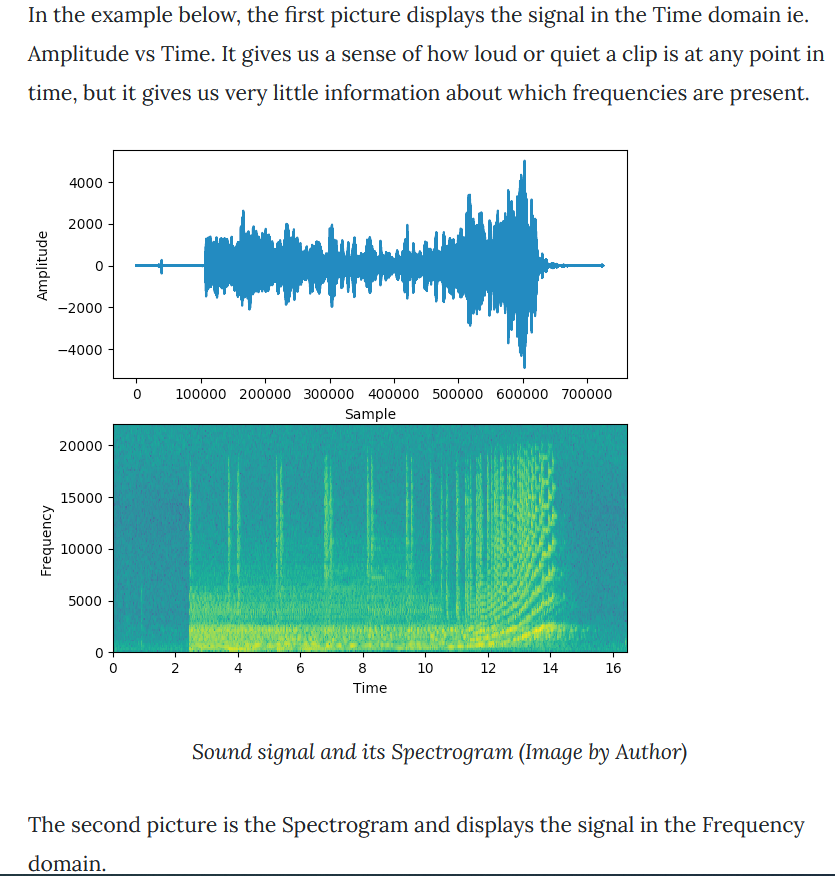


![image.png](attachment:38ada6bd-d588-4dbb-af6f-b2aae728c387.png)

## Spectrogram Vs Mel Spectrogram

https://towardsdatascience.com/audio-deep-learning-made-simple-part-2-why-mel-spectrograms-perform-better-aad889a93505/

A Mel Spectrogram makes two important changes relative to a regular Spectrogram that plots Frequency vs Time.

    It uses the Mel Scale instead of Frequency on the y-axis.
    It uses the Decibel Scale instead of Amplitude to indicate colors.

For deep learning models, we usually use this rather than a simple Spectrogram.

In summary, mel spectrograms are more attuned to lower frequencies and better mimic human perception of audio. It leads to images which are denser with information and are better for machine learning.

In [7]:
def get_mel_spectrogram_librosa(audio_tensor, label):
    def _process_audio(audio_np):
        # Handle Stereo-to-Mono conversion
        if len(audio_np.shape) > 1 and audio_np.shape[-1] > 1:
            audio_np = np.mean(audio_np, axis=-1)

        audio_np = np.squeeze(audio_np)

        # Generate the Mel Spectrogram
        S = librosa.feature.melspectrogram(
            y=audio_np,
            sr=48000,
            n_fft=255,
            hop_length=128,
            n_mels=80,
            fmin=80.0,
            fmax=8000.0
        )

        log_S = librosa.power_to_db(S, ref=np.max)
        return log_S.astype(np.float32)[..., np.newaxis]

    [mel_spec] = tf.py_function(_process_audio, [audio_tensor], [tf.float32])

    # Define the expected shape for the single image
    mel_spec.set_shape([80, None, 1])

    return mel_spec, label

In [8]:

def prepare_dataset(ds):
    return ds.map(get_mel_spectrogram_librosa, num_parallel_calls=tf.data.AUTOTUNE)

train_spectrogram_ds = prepare_dataset(train_ds)
val_spectrogram_ds = prepare_dataset(val_ds)

# Now it's safe to batch!
train_spectrogram_ds = train_spectrogram_ds.batch(64).cache().prefetch(tf.data.AUTOTUNE)
val_spectrogram_ds = val_ds.map(get_mel_spectrogram_librosa).batch(64).prefetch(tf.data.AUTOTUNE)


H:\conda_envs\gpu_env\lib\site-packages\librosa\feature\spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)


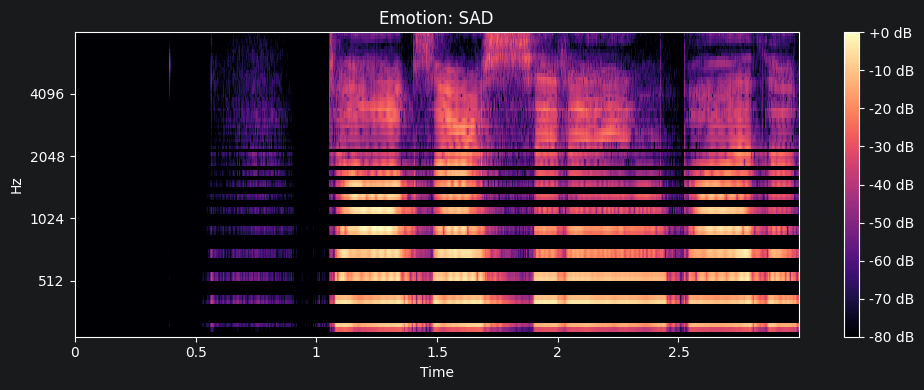

Final Spectrogram Shape: (80, 1125, 1)


In [9]:
import matplotlib.pyplot as plt
import librosa.display
import numpy as np

# 1. Grab one batch from the transformed dataset
for spec_batch, label_batch in train_spectrogram_ds.take(1):

    # Extract the first sample and label
    # Current shape: (Mel_Bins, Time, 1) or (Time, Mel_Bins, 1)
    # Most Librosa-style transforms result in (80, Time, 1)
    single_spec = spec_batch[0].numpy()
    single_label = label_batch[0].numpy()

    # Remove the channel dimension (the '1' at the end)
    # Resulting shape: (80, Time)
    plot_data = np.squeeze(single_spec)

    plt.figure(figsize=(10, 4))

    # Use librosa's specialized display tool
    # 'x_axis' and 'y_axis' parameters add the time/mel labels for you
    img = librosa.display.specshow(
        plot_data,
        sr=48000,
        hop_length=128,
        x_axis='time',
        y_axis='mel',
        fmin=80.0,
        fmax=8000.0,
        cmap='magma'
    )

    plt.colorbar(img, format='%+2.0f dB')
    plt.title(f"Emotion: {label_names[single_label].upper()}")
    plt.tight_layout()
    plt.show()

    print(f"Final Spectrogram Shape: {single_spec.shape}")
    break # Only need one batch

# Model Training

## Model Architecture

In [10]:
from tensorflow.keras import layers, models

# The input shape is (Time, Frequencies, Channels)
# We exclude the 'None' (batch size)
input_shape = (1124, 80, 1)
num_labels = len(label_names)

norm_layer = layers.Normalization()
norm_layer.adapt(data=train_spectrogram_ds.map(map_func=lambda spec, label: spec))


for example_spec, example_label in train_spectrogram_ds.take(1):
    input_shape = example_spec.shape[1:] # This gets (Time, 80, 1)
    print(f"Corrected Input Shape: {input_shape}")

model = models.Sequential([
    layers.Input(shape=input_shape),
    # Downsample the input.
    layers.Resizing(32, 32),
    # Normalize.

    # norm_layer,
    layers.Conv2D(32, 3, activation='relu'),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_labels),
])

model.summary()

Corrected Input Shape: (80, 1125, 1)
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resizing (Resizing)         (None, 32, 32, 1)         0         
                                                                 
 conv2d (Conv2D)             (None, 30, 30, 32)        320       
                                                                 
 conv2d_1 (Conv2D)           (None, 28, 28, 64)        18496     
                                                                 
 max_pooling2d (MaxPooling2D  (None, 14, 14, 64)       0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 14, 14, 64)        0         
                                                                 
 flatten (Flatten)           (None, 12544)             0         
                   

In [11]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'],
)

# It's highly recommended to use EarlyStopping so you don't waste time
# if the model stops improving.
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_spectrogram_ds,
    validation_data=val_spectrogram_ds,
    epochs=50, # The early stopping will likely cut this shorter
    callbacks=[early_stopping]
)

Epoch 1/50
31/31 [==============================] - 6s 80ms/step - loss: 11.0561 - accuracy: 0.1376 - val_loss: 2.0768 - val_accuracy: 0.1612
Epoch 2/50
31/31 [==============================] - 2s 77ms/step - loss: 2.0723 - accuracy: 0.1519 - val_loss: 2.0679 - val_accuracy: 0.1571
Epoch 3/50
31/31 [==============================] - 2s 78ms/step - loss: 2.0601 - accuracy: 0.1682 - val_loss: 2.0462 - val_accuracy: 0.1449
Epoch 4/50
31/31 [==============================] - 2s 81ms/step - loss: 2.0438 - accuracy: 0.1656 - val_loss: 2.0278 - val_accuracy: 0.1347
Epoch 5/50
31/31 [==============================] - 3s 84ms/step - loss: 2.0314 - accuracy: 0.1651 - val_loss: 2.0066 - val_accuracy: 0.1755
Epoch 6/50
31/31 [==============================] - 2s 82ms/step - loss: 2.0013 - accuracy: 0.2034 - val_loss: 1.9630 - val_accuracy: 0.2102
Epoch 7/50
31/31 [==============================] - 2s 81ms/step - loss: 1.9794 - accuracy: 0.2253 - val_loss: 1.9417 - val_accuracy: 0.2531
Epoch 8/50
3

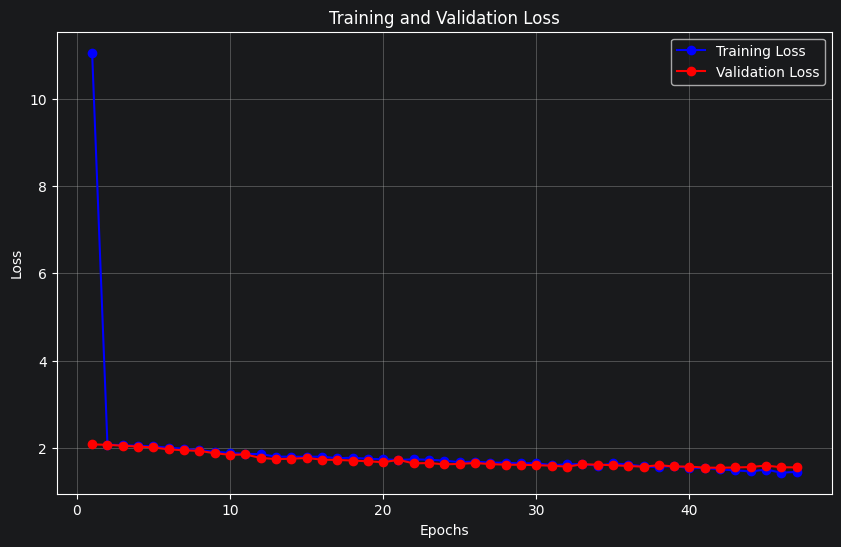

In [12]:
import matplotlib.pyplot as plt

# Assuming 'history' is the variable returned by model.fit()
def plot_loss(history):
    plt.figure(figsize=(10, 6))

    # Extract loss values
    train_loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(train_loss) + 1)

    # Plotting
    plt.plot(epochs, train_loss, 'bo-', label='Training Loss') # 'bo-' = blue dots/line
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss') # 'ro-' = red dots/line

    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.show()

plot_loss(history)

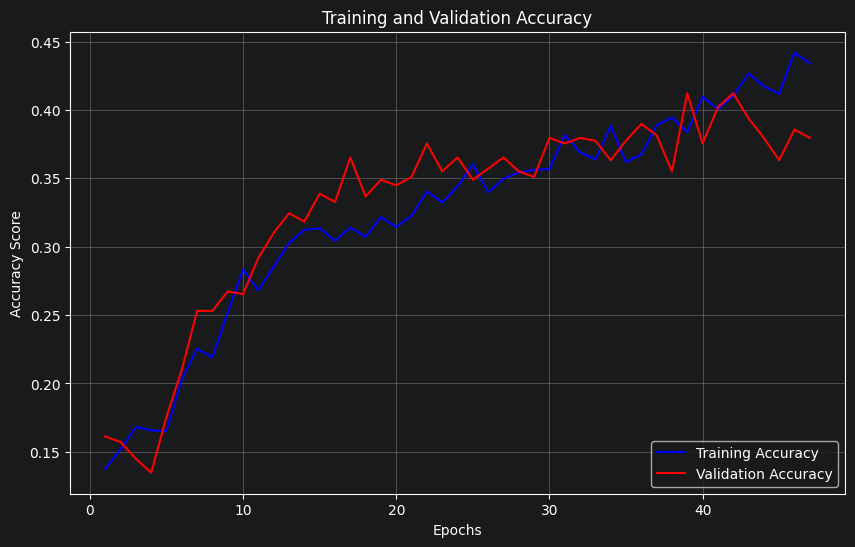

In [13]:

def plot_accuracy(history):
    plt.figure(figsize=(10, 6))
    
    # Extract accuracy values
    # Note: Use 'acc' and 'val_acc' for older versions of Keras
    train_acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    epochs = range(1, len(train_acc) + 1)

    # Plotting
    plt.plot(epochs, train_acc, 'b-', label='Training Accuracy') 
    plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy') 
    
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy Score')
    plt.legend(loc='lower right')
    plt.grid(True)
    
    plt.savefig('accuracy_plot.png')
    
plot_accuracy(history)

In [15]:
print(f"Model stopped at epoch: {early_stopping.stopped_epoch}")

test_loss, test_acc = model.evaluate(val_spectrogram_ds, verbose=2)
print('Accuracy for ADAM')
print(f'\nTest accuracy: {test_acc}')

compilers_results ={'adam':test_acc }

Model stopped at epoch: 46
8/8 - 2s - loss: 1.5423 - accuracy: 0.4122 - 2s/epoch - 287ms/step
Accuracy for ADAM

Test accuracy: 0.41224488615989685


## VGG

In [16]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models, optimizers

# 1. Update the input shape to match your ACTUAL Mel Spectrograms
# Based on your previous run, it's something like (80, 282, 1) or (80, 1125, 1)
# Let's pull it from your input_shape variable
mel_height = 80
mel_width = input_shape[1] # Use the width from your dataset

model_vgg = models.Sequential([
    layers.Input(shape=(mel_height, mel_width, 1)),

    # OPTIONAL: Use Resizing only if the image is too large for your GPU
    # but keep it at a decent resolution (e.g., 128x128 or 224x224)
    # layers.Resizing(128, 256),

    # Convert 1 channel (Grayscale) to 3 channels (RGB) for VGG16
    layers.Conv2D(3, (3, 3), padding='same'),

    # The VGG16 Base (Pre-trained on ImageNet)
    VGG16(weights='imagenet', include_top=False, input_shape=(None, None, 3)),

    # Global Average Pooling is better than Flatten for audio
    layers.GlobalAveragePooling2D(),

    # Final Classification Layers
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_labels, activation='softmax')
])

# --- FINE-TUNING STEP ---
# Initially, we freeze the whole VGG base
model_vgg.layers[1].trainable = False

model_vgg.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4), # Low learning rate for transfer learning
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_vgg.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 80, 1125, 3)       30        
                                                                 
 vgg16 (Functional)          (None, None, None, 512)   14714688  
                                                                 
 global_average_pooling2d (G  (None, 512)              0         
 lobalAveragePooling2D)                                          
                                                                 
 dense_2 (Dense)             (None, 512)               262656    
                                                                 
 dropout_2 (Dropout)         (None, 512)               0         
                                                                 
 dense_3 (Dense)             (None, 8)                 4104      
                                                      

In [18]:
# Unfreeze the VGG16 base
model_vgg.layers[1].trainable = True

# Re-compile with an EXTREMELY low learning rate
# You don't want to "break" the pre-trained weights, just nudge them
model_vgg.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Continue training
history_finetune = model_vgg.fit(train_spectrogram_ds, validation_data=val_spectrogram_ds, epochs=50)

Epoch 1/50
31/31 [==============================] - 52s 2s/step - loss: 1.8693 - accuracy: 0.2905 - val_loss: 1.7469 - val_accuracy: 0.3082
Epoch 2/50
31/31 [==============================] - 50s 2s/step - loss: 1.7618 - accuracy: 0.3226 - val_loss: 1.6398 - val_accuracy: 0.3939
Epoch 3/50
31/31 [==============================] - 50s 2s/step - loss: 1.6808 - accuracy: 0.3415 - val_loss: 1.5702 - val_accuracy: 0.4245
Epoch 4/50
31/31 [==============================] - 50s 2s/step - loss: 1.6150 - accuracy: 0.3818 - val_loss: 1.5031 - val_accuracy: 0.4429
Epoch 5/50
31/31 [==============================] - 50s 2s/step - loss: 1.5161 - accuracy: 0.4292 - val_loss: 1.4624 - val_accuracy: 0.4571
Epoch 6/50
31/31 [==============================] - 50s 2s/step - loss: 1.4538 - accuracy: 0.4572 - val_loss: 1.3941 - val_accuracy: 0.4776
Epoch 7/50
31/31 [==============================] - 50s 2s/step - loss: 1.3748 - accuracy: 0.4934 - val_loss: 1.3229 - val_accuracy: 0.5265
Epoch 8/50
31/31 [==

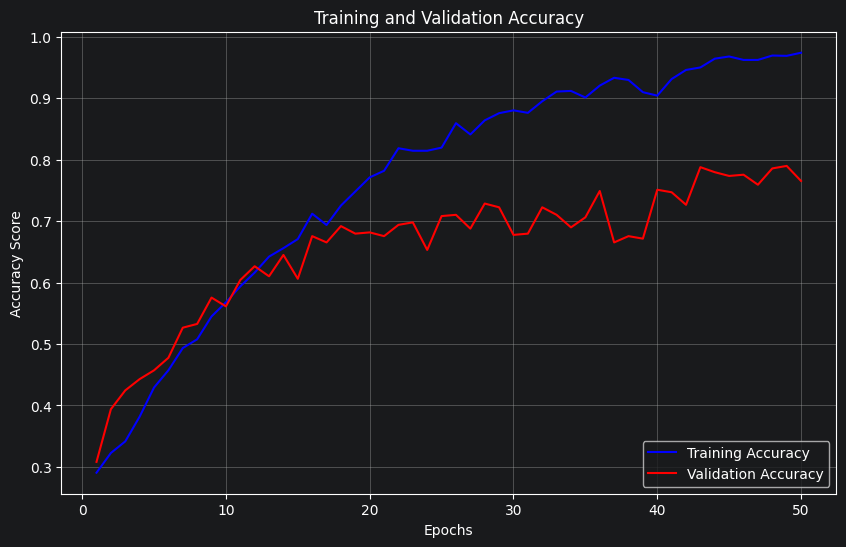

In [20]:

def plot_accuracy(history):
    plt.figure(figsize=(10, 6))

    # Extract accuracy values
    # Note: Use 'acc' and 'val_acc' for older versions of Keras
    train_acc = history_finetune.history['accuracy']
    val_acc = history_finetune.history['val_accuracy']
    epochs = range(1, len(train_acc) + 1)

    # Plotting
    plt.plot(epochs, train_acc, 'b-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')

    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy Score')
    plt.legend(loc='lower right')
    plt.grid(True)

    plt.savefig('accuracy_plot.png')

plot_accuracy(history)